In [1]:
!pip install -q transformers datasets accelerate gradio scikit-learn seaborn matplotlib pandas
!pip install -q kaggle

In [2]:
import os, re, json, pickle, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


In [3]:
CONFIG = {
    'model_name'  : 'distilbert-base-uncased',
    'max_length'  : 256,
    'batch_size'  : 16,
    'epochs'      : 3,
    'lr'          : 2e-5,
    'weight_decay': 0.01,
    'warmup_ratio': 0.1,
    'val_size'    : 0.1,
    'test_size'   : 0.1,
    'random_seed' : 42,
    'num_labels'  : 2,
}

torch.manual_seed(CONFIG['random_seed'])
np.random.seed(CONFIG['random_seed'])
print('Config:', json.dumps(CONFIG, indent=2))

Config: {
  "model_name": "distilbert-base-uncased",
  "max_length": 256,
  "batch_size": 16,
  "epochs": 3,
  "lr": 2e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "val_size": 0.1,
  "test_size": 0.1,
  "random_seed": 42,
  "num_labels": 2
}


Day 1–2: Dataset Understanding

In [4]:
import io

DEMO_CSV = '''text,label_id
Scientists confirm new cancer treatment shows 90% success rate in trials,0
Government secretly adding mind control chemicals to tap water,1
Federal Reserve raises interest rates by 0.25% amid inflation concerns,0
Aliens have landed in New Mexico says anonymous source,1
New climate report shows record high global temperatures in 2023,0
Vaccines contain microchips to track your location,1
Tech giant reports record quarterly earnings beating analyst forecasts,0
Celebrity fakes death to escape IRS investigation,1
Study links regular Mediterranean diet to longer lifespan,0
Mayor caught on camera confessing to secret society membership,1
Electric vehicle adoption accelerates as battery costs fall further,0
Deep state operatives are controlling all major elections,1
New bridge construction project will create thousands of local jobs,0
BREAKING doctors are hiding simple cure for all cancers,1
University researchers discover new antibiotic that fights resistant bacteria,0
Government plans to ban cash and force digital currency on citizens,1
Stock markets close higher after positive economic data,0
NASA faked all moon landings says former employee,1
City council approves new affordable housing development plan,0
Bill Gates funding secret program to reduce world population,1
'''

df_raw = pd.read_csv(io.StringIO(DEMO_CSV))
df_raw['label'] = df_raw['label_id'].map({0: 'Real', 1: 'Fake'})
print(f'Loaded {len(df_raw)} rows')
print('Note: Replace the demo CSV with the real Kaggle dataset for best results!')
df_raw.head()

Loaded 20 rows
Note: Replace the demo CSV with the real Kaggle dataset for best results!


,text,label_id,label
0,Scientists confirm new cancer treatment shows ...,0,Real
1,Government secretly adding mind control chemic...,1,Fake
2,Federal Reserve raises interest rates by 0.25%...,0,Real
3,Aliens have landed in New Mexico says anonymou...,1,Fake
4,New climate report shows record high global te...,0,Real


Label Distribution:
label
Real    10
Fake    10
Name: count, dtype: int64


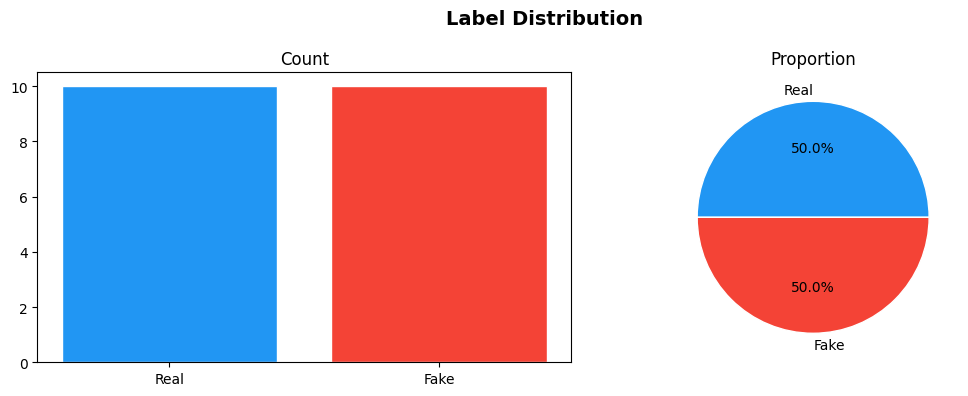


Class imbalance ratio: 1.00x


In [5]:
print('Label Distribution:')
print(df_raw['label'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Label Distribution', fontsize=14, fontweight='bold')
counts = df_raw['label'].value_counts()
colors = ['#2196F3', '#F44336']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white')
axes[0].set_title('Count')
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Proportion')
plt.tight_layout()
plt.show()

ratio = counts.max() / counts.min()
print(f'\nClass imbalance ratio: {ratio:.2f}x')
if ratio > 1.5:
    print('⚠️  Imbalance detected. Consider weighted loss (Day 8).')

Text Length by Class:
      word_count                                      char_count             \
           count mean  std  min  25%  50%   75%   max      count  mean  std   
label                                                                         
Fake        10.0  8.6  1.2  7.0  8.0  9.0   9.0  11.0       10.0  56.5  6.2   
Real        10.0  9.2  1.0  8.0  8.2  9.0  10.0  11.0       10.0  66.0  6.8   

                                     
        min   25%   50%   75%   max  
label                                
Fake   49.0  51.0  56.0  61.5  67.0  
Real   55.0  61.8  67.0  70.0  77.0  


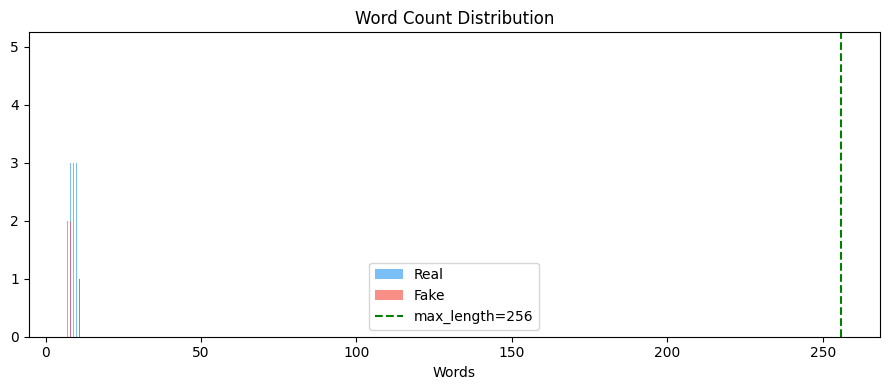

In [6]:
df_raw['word_count'] = df_raw['text'].astype(str).str.split().str.len()
df_raw['char_count'] = df_raw['text'].astype(str).str.len()

print('Text Length by Class:')
print(df_raw.groupby('label')[['word_count','char_count']].describe().round(1))

fig, ax = plt.subplots(figsize=(9, 4))
for label, color in zip(['Real','Fake'], colors):
    ax.hist(df_raw[df_raw['label']==label]['word_count'],
            bins=20, alpha=0.6, label=label, color=color)
ax.axvline(CONFIG['max_length'], color='green', linestyle='--', label=f"max_length={CONFIG['max_length']}")
ax.set_title('Word Count Distribution'); ax.set_xlabel('Words'); ax.legend()
plt.tight_layout(); plt.show()

In [7]:
print('5 Sample Entries:')
print('='*70)
sample = df_raw.groupby('label').apply(lambda x: x.sample(min(3, len(x)), random_state=42)).reset_index(drop=True)
for _, row in sample.head(5).iterrows():
    print(f"  Label: [{row['label']}]")
    print(f"  Text : {str(row['text'])[:200]}")
    print('  ' + '-'*66)

5 Sample Entries:
  Label: [Fake]
  Text : NASA faked all moon landings says former employee
  ------------------------------------------------------------------
  Label: [Fake]
  Text : Aliens have landed in New Mexico says anonymous source
  ------------------------------------------------------------------
  Label: [Fake]
  Text : Deep state operatives are controlling all major elections
  ------------------------------------------------------------------
  Label: [Real]
  Text : Stock markets close higher after positive economic data
  ------------------------------------------------------------------
  Label: [Real]
  Text : Federal Reserve raises interest rates by 0.25% amid inflation concerns
  ------------------------------------------------------------------


In [9]:
def clean_text(text):
    if not isinstance(text, str): return ''
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_raw['text'] = df_raw['text'].apply(clean_text)
df = df_raw.dropna(subset=['text', 'label']).copy()
df = df[df['text'].str.len() > 10].reset_index(drop=True)
print(f'After cleaning: {len(df)} samples')

After cleaning: 20 samples


Day 3: Tokenization & Data Preparation

In [10]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print(f'Tokenizer: {CONFIG["model_name"]}')
print(f'Vocab size: {tokenizer.vocab_size:,}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: distilbert-base-uncased
Vocab size: 30,522


In [11]:
texts  = df['text'].tolist()
labels = df['label_id'].astype(int).tolist()

X_tv, X_test, y_tv, y_test = train_test_split(
    texts, labels, test_size=CONFIG['test_size'],
    stratify=labels, random_state=CONFIG['random_seed']
)
val_r = CONFIG['val_size'] / (1 - CONFIG['test_size'])
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=val_r,
    stratify=y_tv, random_state=CONFIG['random_seed']
)
print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

Train: 16  |  Val: 2  |  Test: 2


In [12]:
def tokenize(texts):
    return tokenizer(
        texts, max_length=CONFIG['max_length'],
        padding='max_length', truncation=True,
        return_attention_mask=True, return_token_type_ids=True,
    )

print('Tokenizing...')
train_enc = tokenize(X_train)
val_enc   = tokenize(X_val)
test_enc  = tokenize(X_test)
print('Done!')

print('\nExample tokenized output (index 0):')
ids    = train_enc['input_ids'][0]
tokens = tokenizer.convert_ids_to_tokens(ids)
non_pad = sum(1 for m in train_enc['attention_mask'][0] if m == 1)
print(f'  Non-padding tokens : {non_pad}')
print(f'  First 15 tokens    : {tokens[:15]}')

print(f'\nInput tensor shapes:')
for split, enc in [('Train', train_enc), ('Val', val_enc), ('Test', test_enc)]:
    n, s = len(enc['input_ids']), len(enc['input_ids'][0])
    print(f'  {split:6s}  input_ids: ({n}, {s})')

Tokenizing...
Done!

Example tokenized output (index 0):
  Non-padding tokens : 14
  First 15 tokens    : ['[CLS]', 'scientists', 'confirm', 'new', 'cancer', 'treatment', 'shows', '90', '%', 'success', 'rate', 'in', 'trials', '[SEP]', '[PAD]']

Input tensor shapes:
  Train   input_ids: (16, 256)
  Val     input_ids: (2, 256)
  Test    input_ids: (2, 256)


In [13]:
class FakeNewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = FakeNewsDataset(train_enc, y_train)
val_dataset   = FakeNewsDataset(val_enc,   y_val)
test_dataset  = FakeNewsDataset(test_enc,  y_test)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'], shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False)

print(f'DataLoaders ready: {len(train_loader)} train batches, {len(val_loader)} val batches')

DataLoaders ready: 1 train batches, 1 val batches


Day 4–5: Model Fine-Tuning

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['model_name'],
    num_labels=2,
    id2label={0: 'Real', 1: 'Fake'},
    label2id={'Real': 0, 'Fake': 1},
)
model.to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model   : {CONFIG["model_name"]}')
print(f'Params  : {total:,}  (trainable: {trainable:,})')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model   : distilbert-base-uncased
Params  : 66,955,010  (trainable: 66,955,010)


In [15]:
optimizer    = AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
total_steps  = len(train_loader) * CONFIG['epochs']
warmup_steps = int(total_steps * CONFIG['warmup_ratio'])
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
print(f'Total training steps: {total_steps}  |  Warmup steps: {warmup_steps}')

Total training steps: 3  |  Warmup steps: 0


In [16]:
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, preds_all, labels_all = 0.0, [], []
    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['labels'].to(DEVICE)
        kw   = {'input_ids': ids, 'attention_mask': mask, 'labels': lbls}
        if 'token_type_ids' in batch:
            kw['token_type_ids'] = batch['token_type_ids'].to(DEVICE)
        optimizer.zero_grad()
        out = model(**kw)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += out.loss.item()
        preds_all.extend(torch.argmax(out.logits, 1).cpu().numpy())
        labels_all.extend(lbls.cpu().numpy())
    return total_loss / len(loader), accuracy_score(labels_all, preds_all)

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []
    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['labels'].to(DEVICE)
        kw   = {'input_ids': ids, 'attention_mask': mask, 'labels': lbls}
        if 'token_type_ids' in batch:
            kw['token_type_ids'] = batch['token_type_ids'].to(DEVICE)
        out = model(**kw)
        total_loss += out.loss.item()
        preds_all.extend(torch.argmax(out.logits, 1).cpu().numpy())
        labels_all.extend(lbls.cpu().numpy())
    return total_loss / len(loader), accuracy_score(labels_all, preds_all)


history = []
best_val_acc = 0.0
os.makedirs('/content/models', exist_ok=True)

for epoch in range(1, CONFIG['epochs'] + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler)
    vl_loss, vl_acc = eval_epoch(model, val_loader)
    elapsed = time.time() - t0

    print(f'Epoch {epoch}/{CONFIG["epochs"]} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | '
          f'{elapsed:.0f}s')

    history.append({'epoch': epoch, 'train_loss': tr_loss, 'train_acc': tr_acc,
                    'val_loss': vl_loss, 'val_acc': vl_acc})

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        model.save_pretrained('/content/models/best_model')
        tokenizer.save_pretrained('/content/models/best_model')
        print(f'  ✅ Saved best model (val_acc={best_val_acc:.4f})')

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Epoch 1/3 | Train Loss: 0.7007 Acc: 0.5000 | Val Loss: 0.6697 Acc: 1.0000 | 1s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Saved best model (val_acc=1.0000)
Epoch 2/3 | Train Loss: 0.6844 Acc: 0.5625 | Val Loss: 0.6662 Acc: 1.0000 | 0s
Epoch 3/3 | Train Loss: 0.6682 Acc: 0.7500 | Val Loss: 0.6641 Acc: 1.0000 | 0s

Best Val Accuracy: 1.0000


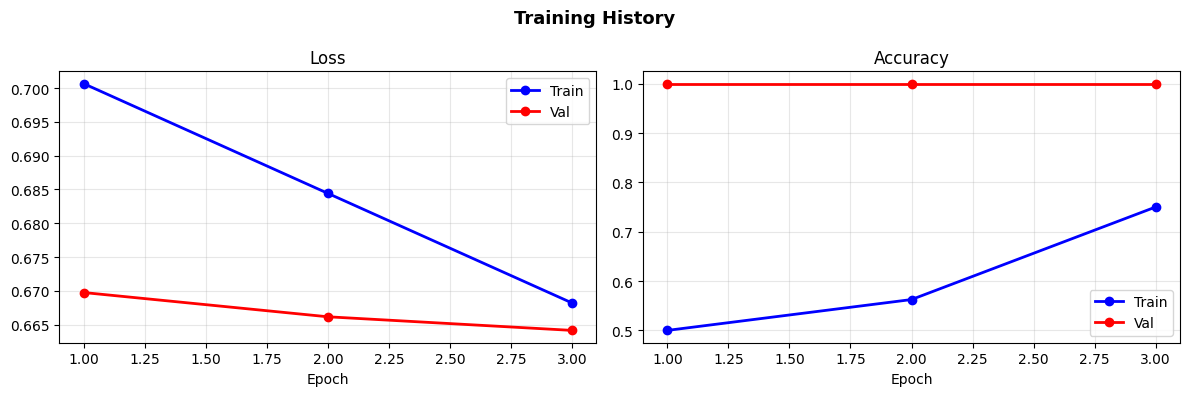

In [17]:
epochs    = [h['epoch']     for h in history]
tr_losses = [h['train_loss'] for h in history]
vl_losses = [h['val_loss']   for h in history]
tr_accs   = [h['train_acc']  for h in history]
vl_accs   = [h['val_acc']    for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Training History', fontsize=13, fontweight='bold')
ax1.plot(epochs, tr_losses, 'b-o', label='Train', linewidth=2)
ax1.plot(epochs, vl_losses, 'r-o', label='Val',   linewidth=2)
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(epochs, tr_accs, 'b-o', label='Train', linewidth=2)
ax2.plot(epochs, vl_accs, 'r-o', label='Val',   linewidth=2)
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Day 6: Evaluation

In [18]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        kw   = {'input_ids': ids, 'attention_mask': mask}
        if 'token_type_ids' in batch:
            kw['token_type_ids'] = batch['token_type_ids'].to(DEVICE)
        out   = model(**kw)
        probs = torch.softmax(out.logits, 1).cpu().numpy()
        all_preds.extend(np.argmax(probs, 1))
        all_probs.extend(probs[:, 1])
        all_labels.extend(batch['labels'].numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

y_true, y_pred, y_probs = get_predictions(model, test_loader)
print('Inference complete.')

Inference complete.


In [19]:
print('Classification Report:')
print('='*60)
print(classification_report(y_true, y_pred, target_names=['Real','Fake'], digits=4))

Classification Report:
              precision    recall  f1-score   support

        Real     0.0000    0.0000    0.0000       1.0
        Fake     0.0000    0.0000    0.0000       1.0

    accuracy                         0.0000       2.0
   macro avg     0.0000    0.0000    0.0000       2.0
weighted avg     0.0000    0.0000    0.0000       2.0



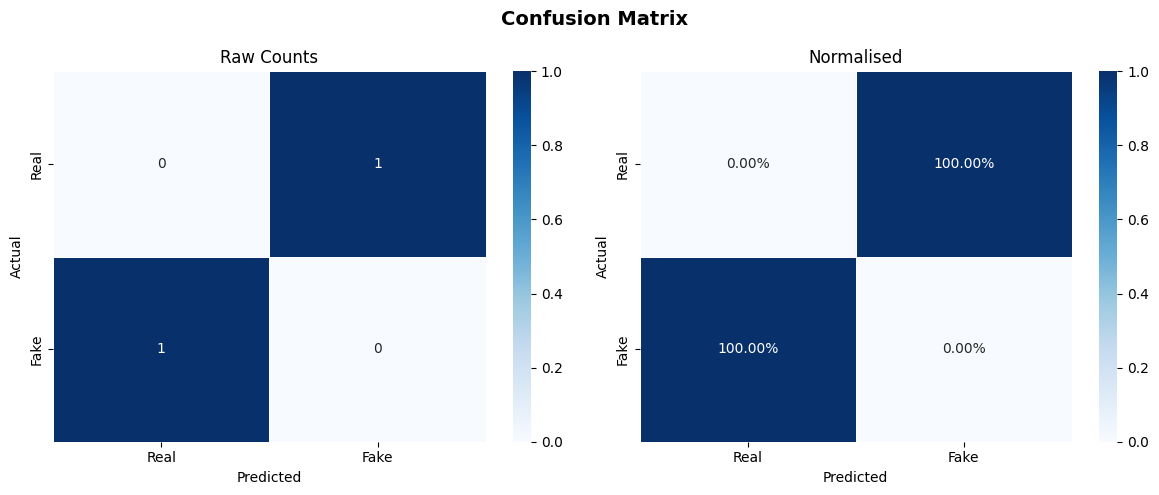

In [20]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrix', fontsize=14, fontweight='bold')
for ax, data, fmt, title in zip(axes, [cm, cm_norm], ['d', '.2%'], ['Raw Counts', 'Normalised']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=['Real','Fake'], yticklabels=['Real','Fake'],
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

 Day 7: Error Analysis

In [21]:
preds_df = pd.DataFrame({
    'text'      : X_test,
    'true_label': ['Real' if l==0 else 'Fake' for l in y_true],
    'pred_label': ['Real' if p==0 else 'Fake' for p in y_pred],
    'fake_prob' : y_probs.round(4),
    'correct'   : y_true == y_pred,
})

errors = preds_df[~preds_df['correct']].copy()
errors['error_type'] = errors.apply(
    lambda r: 'FP (Real→Fake)' if r['true_label']=='Real' else 'FN (Fake→Real)', axis=1
)

print(f'Total errors: {len(errors)} / {len(preds_df)} ({len(errors)/len(preds_df)*100:.1f}%)')
print(f"\nError type breakdown:\n{errors['error_type'].value_counts()}")

print('\nTop 5 High-Confidence Errors:')
print('='*70)
for i, (_, row) in enumerate(errors.sort_values('fake_prob', ascending=False).head(5).iterrows(), 1):
    print(f'[{i}] {row["error_type"]}  (P(Fake)={row["fake_prob"]:.3f})')
    print(f'    {str(row["text"])[:200]}')
    print()

Total errors: 2 / 2 (100.0%)

Error type breakdown:
error_type
FP (Real→Fake)    1
FN (Fake→Real)    1
Name: count, dtype: int64

Top 5 High-Confidence Errors:
[1] FP (Real→Fake)  (P(Fake)=0.506)
    New bridge construction project will create thousands of local jobs

[2] FN (Fake→Real)  (P(Fake)=0.479)
    Vaccines contain microchips to track your location



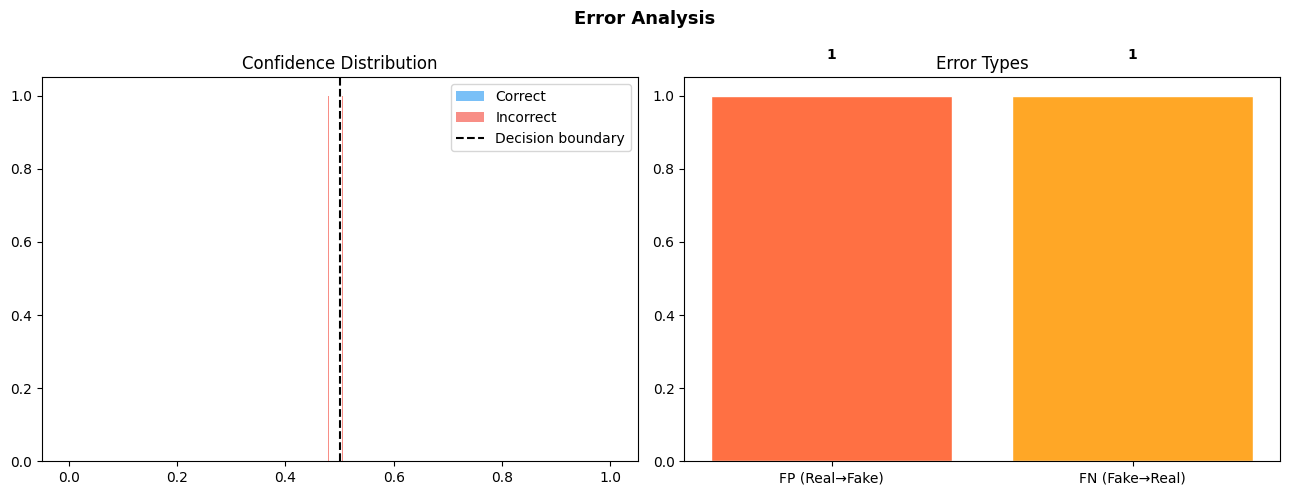

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Error Analysis', fontsize=13, fontweight='bold')


for correct, color, lbl in [(True,'#2196F3','Correct'),(False,'#F44336','Incorrect')]:
    axes[0].hist(preds_df[preds_df['correct']==correct]['fake_prob'],
                 bins=20, alpha=0.6, color=color, label=lbl)
axes[0].axvline(0.5, color='black', linestyle='--', label='Decision boundary')
axes[0].set_title('Confidence Distribution'); axes[0].legend()


ec = errors['error_type'].value_counts()
axes[1].bar(ec.index, ec.values, color=['#FF7043','#FFA726'], edgecolor='white')
axes[1].set_title('Error Types')
for i, v in enumerate(ec.values):
    axes[1].text(i, v+0.1, str(v), ha='center', fontweight='bold')

plt.tight_layout(); plt.show()

Day 8: Model Improvement – Weighted Loss

In [23]:
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
wt = torch.tensor(weights, dtype=torch.float).to(DEVICE)
print(f'Class weights: Real={weights[0]:.4f}, Fake={weights[1]:.4f}')

model_wt = AutoModelForSequenceClassification.from_pretrained(CONFIG['model_name'], num_labels=2)
model_wt.to(DEVICE)
opt_wt = AdamW(model_wt.parameters(), lr=CONFIG['lr'], weight_decay=0.01)
sch_wt = get_linear_schedule_with_warmup(opt_wt, warmup_steps, total_steps)
loss_fn = nn.CrossEntropyLoss(weight=wt)

wt_history = []
for epoch in range(1, CONFIG['epochs'] + 1):
    model_wt.train()
    for batch in train_loader:
        ids = batch['input_ids'].to(DEVICE); mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['labels'].to(DEVICE)
        kw = {'input_ids': ids, 'attention_mask': mask}
        if 'token_type_ids' in batch: kw['token_type_ids'] = batch['token_type_ids'].to(DEVICE)
        opt_wt.zero_grad()
        out = model_wt(**kw)
        loss = loss_fn(out.logits, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_wt.parameters(), 1.0)
        opt_wt.step(); sch_wt.step()
    vl_loss, vl_acc = eval_epoch(model_wt, val_loader)
    wt_history.append({'epoch': epoch, 'val_acc': vl_acc})
    print(f'Weighted | Epoch {epoch} | Val Acc: {vl_acc:.4f}')


print('\nComparison:')
print(f'  Baseline (no weighting) : {history[-1]["val_acc"]:.4f}')
print(f'  Weighted loss           : {wt_history[-1]["val_acc"]:.4f}')

Class weights: Real=1.0000, Fake=1.0000


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Weighted | Epoch 1 | Val Acc: 1.0000
Weighted | Epoch 2 | Val Acc: 1.0000
Weighted | Epoch 3 | Val Acc: 1.0000

Comparison:
  Baseline (no weighting) : 1.0000
  Weighted loss           : 1.0000


Day 9: Deployment with Gradio

In [24]:
import gradio as gr

deploy_model = AutoModelForSequenceClassification.from_pretrained('/content/models/best_model')
deploy_tok   = AutoTokenizer.from_pretrained('/content/models/best_model')
deploy_model.eval().to(DEVICE)

@torch.no_grad()
def classify_news(text):
    if not text.strip():
        return '⚠️ Please enter some text.'
    inputs = deploy_tok(text, max_length=CONFIG['max_length'], padding='max_length',
                        truncation=True, return_tensors='pt')
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()
              if k in ('input_ids', 'attention_mask', 'token_type_ids')}
    out   = deploy_model(**inputs)
    probs = torch.softmax(out.logits, 1).cpu().numpy()[0]
    pred  = np.argmax(probs)
    label = 'REAL' if pred == 0 else 'FAKE'
    conf  = probs[pred] * 100
    emoji = '✅' if pred == 0 else '🚨'
    return f"{emoji} **{label}** (confidence: {conf:.1f}%)\n\nReal: {probs[0]*100:.1f}%  |  Fake: {probs[1]*100:.1f}%"

demo = gr.Interface(
    fn=classify_news,
    inputs=gr.Textbox(label='News Headline or Article', lines=5,
                      placeholder='Paste news text here...'),
    outputs=gr.Markdown(label='Result'),
    title='📰 Fake News Detector',
    description='Fine-tuned BERT / DistilBERT model to classify news as Real or Fake.',
    examples=[
        ['Scientists confirm new cancer treatment shows 90% success in trials.'],
        ['Government secretly adding mind control chemicals to tap water!'],
        ['Federal Reserve raises interest rates by 0.25% amid inflation concerns.'],
    ],
    theme=gr.themes.Soft(),
)

demo.launch(share=True)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://68a9e0b72304b05e15.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
